# Task 1 — EDA on Retail Sales Data
### OIBSIP Data Analytics Internship (Level 1)

**Objective:** Perform a thorough Exploratory Data Analysis on a retail sales dataset to 
uncover patterns, customer behaviour trends, and actionable business insights.

**Dataset:** Superstore Sales Dataset — 9,800 orders, 2015–2018, across the US retail 
chain "Superstore". Columns include order/ship dates, customer segment, region, product 
category, and sales value.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)


## 1. Load and Inspect the Data

In [2]:
df = pd.read_csv("train.csv")
print("Shape:", df.shape)
df.head()


Shape: (9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
df.dtypes


Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code      float64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
dtype: object

In [4]:
df.isnull().sum()


Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

**Observation:** The dataset has 9,800 rows and 18 columns, with only `Postal Code` 
having missing values (11 rows). No other columns need null handling.

## 2. Descriptive Statistics

In [5]:
df.describe()


,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


**Observation:** Sales values range from $0.44 to $22,638.48, with a mean of ~$231 
and a median (50th percentile) of just $54.49 — a strongly right-skewed distribution 
driven by a small number of very high-value orders (likely bulk technology purchases).

## 3. Feature Engineering

Convert date columns to datetime, and engineer a few useful derived features: 
`Order Year`, `Order Month`, `Order Quarter`, and `Shipping Delay` (days between order and 
shipment — useful for the non-obvious insight later).

In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')

df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.to_period('M')
df['Order Quarter'] = df['Order Date'].dt.to_period('Q')
df['Shipping Delay'] = (df['Ship Date'] - df['Order Date']).dt.days

print("Date range:", df['Order Date'].min().date(), "to", df['Order Date'].max().date())


Date range: 2015-01-03 to 2018-12-30


## 4. Time Series Analysis

### 4.1 Monthly sales trend

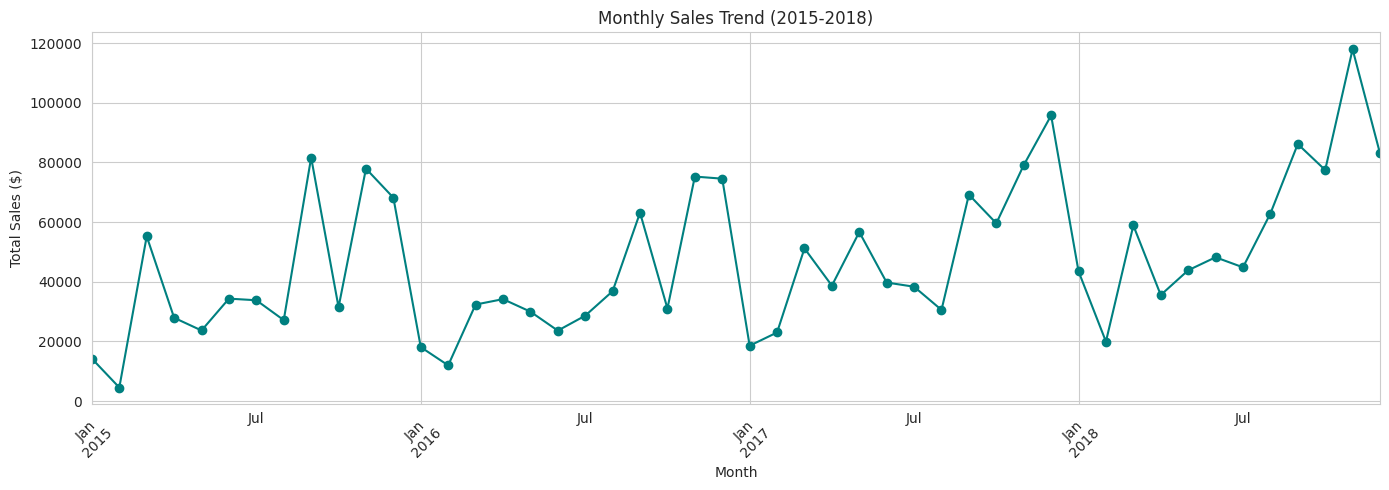

In [7]:
monthly_sales = df.groupby('Order Month')['Sales'].sum()

plt.figure(figsize=(14,5))
monthly_sales.plot(kind='line', marker='o', color='teal')
plt.title("Monthly Sales Trend (2015-2018)")
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("screenshots/01_monthly_sales_trend.png", dpi=100, bbox_inches='tight')
plt.show()


**Observation:** Sales show a clear seasonal pattern, with strong peaks in November 
and December each year (holiday shopping season) and noticeably softer sales in the early 
months of each year (January-February). The overall trend also grows year over year, 
suggesting the business is expanding, not just seasonal.

### 4.2 Quarterly sales trend

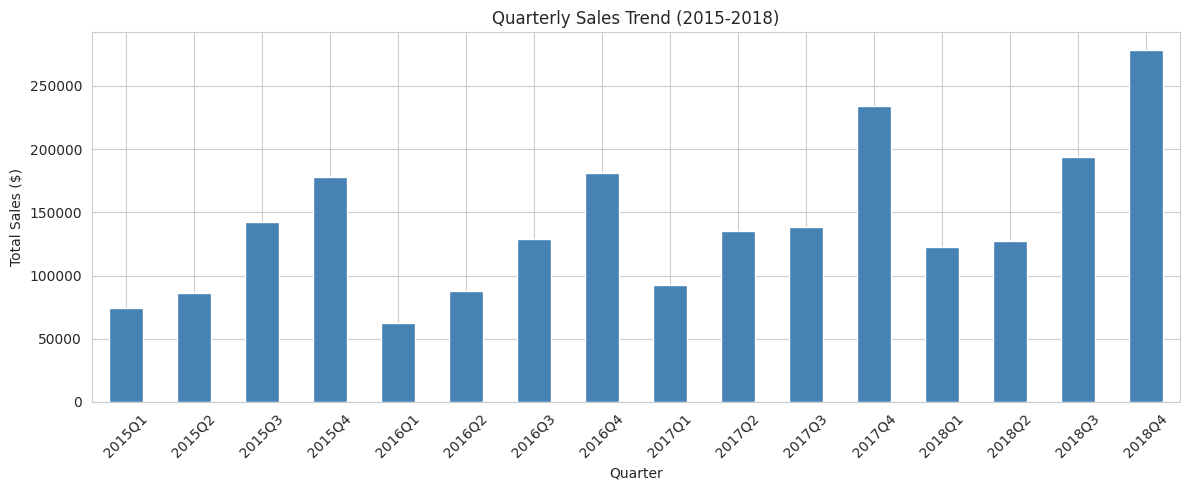

In [8]:
quarterly_sales = df.groupby('Order Quarter')['Sales'].sum()

plt.figure(figsize=(12,5))
quarterly_sales.plot(kind='bar', color='steelblue')
plt.title("Quarterly Sales Trend (2015-2018)")
plt.xlabel("Quarter")
plt.ylabel("Total Sales ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("screenshots/02_quarterly_sales_trend.png", dpi=100, bbox_inches='tight')
plt.show()


**Observation:** Q4 (Oct-Dec) is consistently the strongest quarter across all four 
years, reinforcing the holiday-season pattern seen in the monthly view. Q1 is consistently 
the weakest.

## 5. Customer Analysis

**Note on dataset limitations:** this version of the Superstore dataset does not 
include customer age or gender fields. As a substitute for customer demographics, we 
analyse the available **customer segment** (Consumer / Corporate / Home Office) and 
**geographic region** breakdowns instead.

### 5.1 Customer segment breakdown

In [9]:
segment_stats = df.groupby('Segment')['Sales'].agg(['sum','count','mean']).sort_values('sum', ascending=False)
segment_stats.columns = ['Total Sales', 'Order Count', 'Avg Order Value']
segment_stats


,Total Sales,Order Count,Avg Order Value
Segment,,,
Consumer,1.148061e+06,5101,225.065777
Corporate,6.884941e+05,2953,233.150720
Home Office,4.249822e+05,1746,243.403309


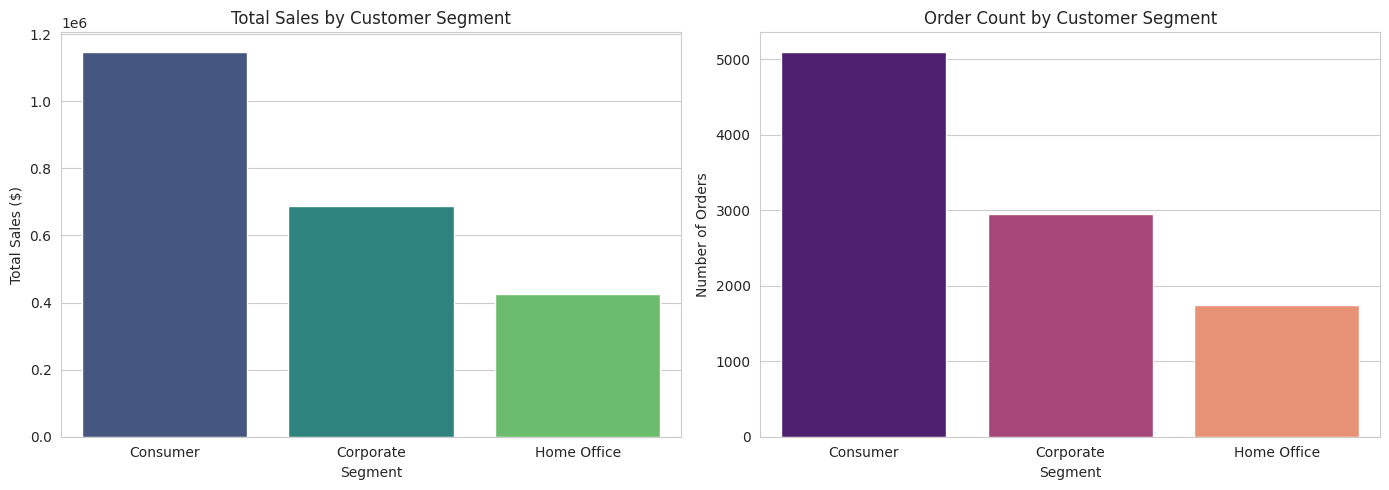

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.barplot(x=segment_stats.index, y=segment_stats['Total Sales'], hue=segment_stats.index, palette='viridis', legend=False, ax=axes[0])
axes[0].set_title("Total Sales by Customer Segment")
axes[0].set_ylabel("Total Sales ($)")

sns.barplot(x=segment_stats.index, y=segment_stats['Order Count'], hue=segment_stats.index, palette='magma', legend=False, ax=axes[1])
axes[1].set_title("Order Count by Customer Segment")
axes[1].set_ylabel("Number of Orders")

plt.tight_layout()
plt.savefig("screenshots/03_segment_breakdown.png", dpi=100, bbox_inches='tight')
plt.show()


**Observation:** The **Consumer** segment drives the most total sales (~$1.15M) and 
order volume (5,101 orders), but **Home Office** customers have the highest average order 
value (~$243), suggesting they buy less often but spend more per order — a useful 
distinction for targeted marketing.

### 5.2 Regional distribution

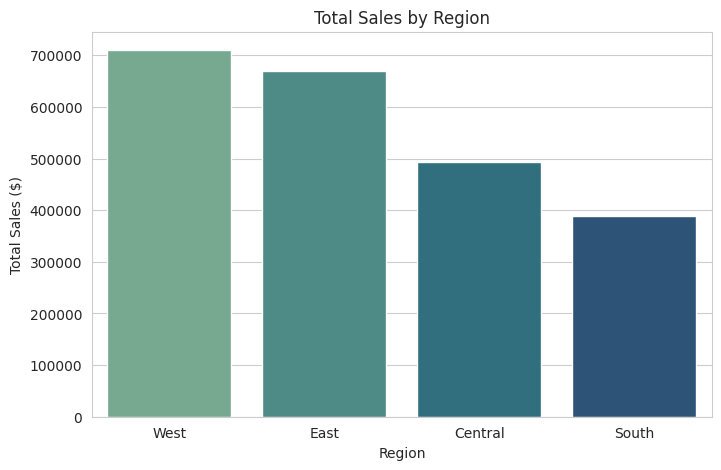

In [11]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=region_sales.index, y=region_sales.values, hue=region_sales.index, palette='crest', legend=False)
plt.title("Total Sales by Region")
plt.ylabel("Total Sales ($)")
plt.savefig("screenshots/04_region_sales.png", dpi=100, bbox_inches='tight')
plt.show()


**Observation:** The **West** region generates the highest sales (~$710K), closely 
followed by the **East** (~$670K). The **South** region trails significantly (~$389K) — 
worth investigating whether this is a market-size issue or an opportunity for expansion.

## 6. Product Analysis

### 6.1 Top 10 best-selling products

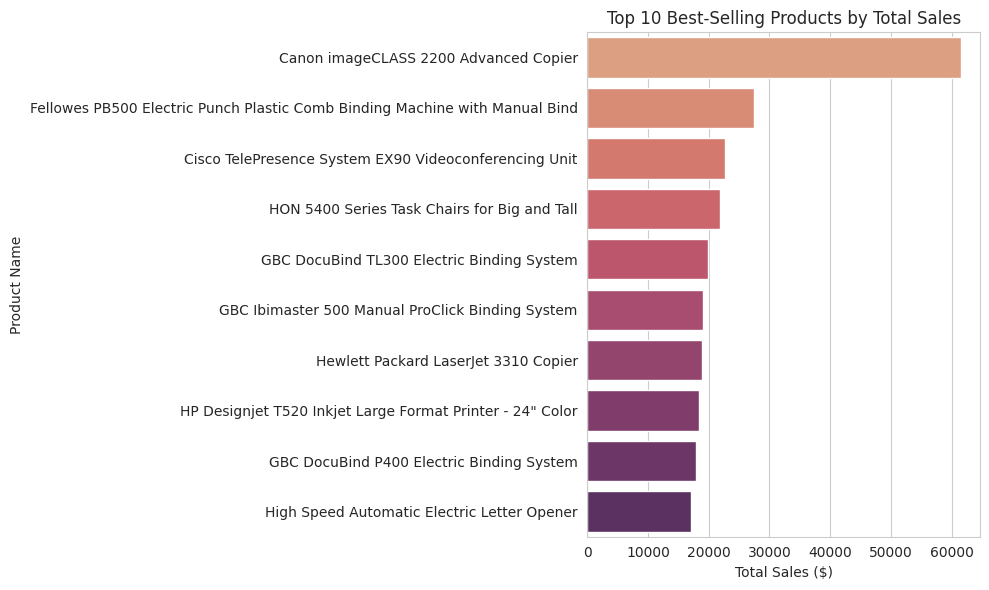

In [12]:
top10_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top10_products.values, y=top10_products.index, hue=top10_products.index, palette='flare', legend=False)
plt.title("Top 10 Best-Selling Products by Total Sales")
plt.xlabel("Total Sales ($)")
plt.tight_layout()
plt.savefig("screenshots/05_top10_products.png", dpi=100, bbox_inches='tight')
plt.show()


**Observation:** The single top product — a Canon imageCLASS copier — generated 
over $61,000 in sales alone, more than double the next closest product. High-value office 
technology (copiers, binding systems, videoconferencing units) dominates the top 10, not 
everyday office supplies.

### 6.2 Revenue by product category

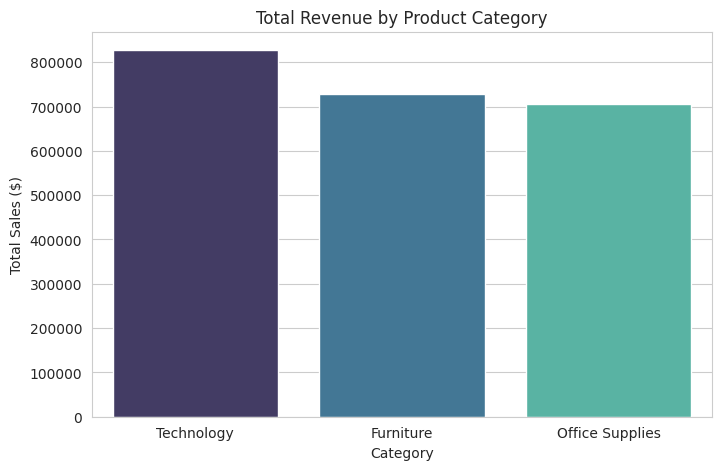

In [13]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=category_sales.index, y=category_sales.values, hue=category_sales.index, palette='mako', legend=False)
plt.title("Total Revenue by Product Category")
plt.ylabel("Total Sales ($)")
plt.savefig("screenshots/06_category_revenue.png", dpi=100, bbox_inches='tight')
plt.show()


**Observation:** **Technology** is the top-earning category (~$827K), narrowly ahead 
of Furniture (~$729K) and Office Supplies (~$705K) — despite Office Supplies almost 
certainly having the highest order count, since individual items are cheap. This points to 
Technology driving revenue through high-value items rather than volume.

## 7. Correlation Heatmap

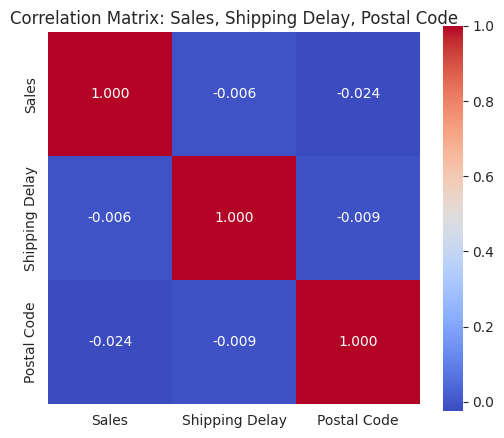

In [14]:
plt.figure(figsize=(6,5))
corr = df[['Sales', 'Shipping Delay', 'Postal Code']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.3f', square=True)
plt.title("Correlation Matrix: Sales, Shipping Delay, Postal Code")
plt.savefig("screenshots/07_correlation_heatmap.png", dpi=100, bbox_inches='tight')
plt.show()


**Observation:** None of the available numeric variables correlate meaningfully with 
Sales — shipping delay (-0.006) and postal code (-0.024) are both essentially unrelated to 
order value. This isn't surprising: this dataset's numeric fields are limited, and Sales 
is driven far more by *what* is bought (product/category) than by *when* it ships or 
*where* it ships to.

## 8. Additional Insight: Shipping Mode vs. Sales

A non-obvious angle: does how an order ships relate to its value or how the business 
uses different shipping speeds?

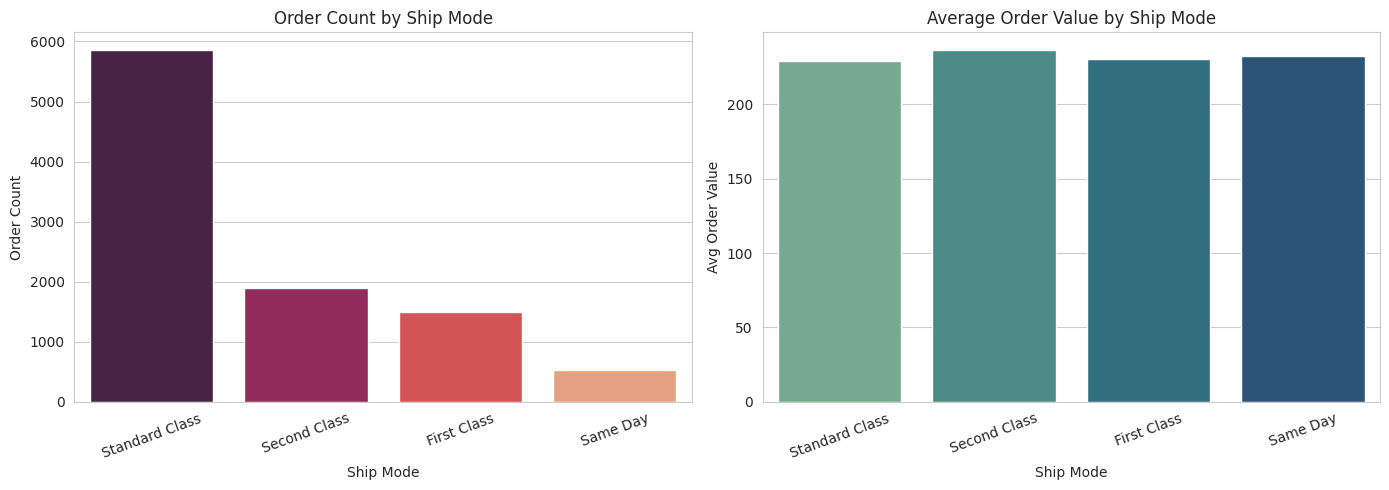

In [15]:
shipmode_stats = df.groupby('Ship Mode')['Sales'].agg(['sum','mean','count']).sort_values('count', ascending=False)
shipmode_stats.columns = ['Total Sales', 'Avg Order Value', 'Order Count']

fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.barplot(x=shipmode_stats.index, y=shipmode_stats['Order Count'], hue=shipmode_stats.index, palette='rocket', legend=False, ax=axes[0])
axes[0].set_title("Order Count by Ship Mode")
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(x=shipmode_stats.index, y=shipmode_stats['Avg Order Value'], hue=shipmode_stats.index, palette='crest', legend=False, ax=axes[1])
axes[1].set_title("Average Order Value by Ship Mode")
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig("screenshots/08_shipmode_analysis.png", dpi=100, bbox_inches='tight')
plt.show()


**Observation:** **Standard Class** dominates order volume (5,859 of 9,800 orders, 
~60%), while **Second Class** has the highest average order value (~$237). Customers don't 
appear to pay for faster shipping on higher-value orders — average order value is fairly 
flat (~$228-237) across all four shipping modes, suggesting shipping choice isn't strongly 
tied to purchase value in this dataset.

## 9. Conclusions and Business Recommendations

**Key findings:**
- Sales are strongly seasonal, peaking every Q4 (Oct-Dec), with Q1 consistently the 
  weakest quarter across all four years in the data.
- Technology is the top revenue category despite likely lower order volume than Office 
  Supplies — it's driven by a small number of very high-value purchases (e.g. copiers, 
  binding systems).
- The West and East regions outperform the South by a wide margin.
- Home Office customers spend more per order on average than Consumer or Corporate 
  customers, despite ordering less frequently.

**Actionable recommendations:**
1. **Plan inventory and staffing around the Q4 peak.** Given the consistent Oct-Dec surge 
   across all four years, the business should front-load Technology and Furniture stock 
   ahead of Q4 and consider a targeted Q1 promotion to smooth out the post-holiday slump.
2. **Double down on high-value Technology products.** Since a handful of big-ticket items 
   (copiers, binding systems) drive outsized revenue, consider a dedicated sales push or 
   bundling strategy around these products, and investigate whether similar high-margin 
   items exist in the current catalogue that aren't yet top sellers.
3. **Investigate the South region's underperformance.** With sales roughly 45% lower than 
   the West, it's worth determining whether this reflects a smaller addressable market or 
   a gap in marketing/distribution reach — the answer should drive whether South becomes 
   an expansion target or is deprioritised.

## 10. Tech Stack
Python, pandas, numpy, matplotlib, seaborn, Jupyter Notebook
